## Baseline Modeling and Evaluation

In [3]:
%load_ext autoreload
%autoreload 2

Import libraries

In [4]:
import sys
from pathlib import Path

project_root = Path.resolve(Path.cwd() / '../..')
if str(project_root) not in sys.path: sys.path.insert(0, str(project_root))

In [5]:
import logging
logging.getLogger("mlflow").setLevel(logging.WARNING)
logging.getLogger("alembic").setLevel(logging.WARNING)

Set up MLflow tracking URI and experiment name

In [6]:
import mlflow
import os
from alembic.util import CommandError

try:
    os.makedirs(project_root / "mlflow", exist_ok=True)
    mlflow.set_tracking_uri(f"sqlite:///{project_root}/mlflow/mlflow.db")

    mlflow.set_registry_uri(f"sqlite:///{project_root}/mlflow/mlflow.db")

    # set storage location for mlflow artifacts
    artifact_dir = project_root / "mlflow" / "artifacts"

    artifact_dir.mkdir(parents=True, exist_ok=True)
    experiment_name = "Production Time Prediction"

    if mlflow.get_experiment_by_name(experiment_name) is None:
        mlflow.create_experiment(
            name=experiment_name,
            artifact_location=artifact_dir.as_uri()
        )
    mlflow.set_experiment("Production Time Prediction")
except CommandError as e:
    print("MLflow setup failed. If you use Windows to run this notebook, while WSL to manage MLflow,"
          "then make sure MLflow in both environments have exact same version installed.")
    print(f"Error setting up MLflow: {e}")

Read data from silver layer

In [7]:
import pandas as pd

X_train = pd.read_parquet('../../data/split/production_time_train.parquet')
X_test = pd.read_parquet('../../data/split/production_time_test.parquet')

y_train = pd.read_parquet('../../data/split/production_time_train_target.parquet')['process_time']
y_test = pd.read_parquet('../../data/split/production_time_test_target.parquet')['process_time']

In [8]:
display(X_train.dtypes)

op_w            float32
op_l            float32
wire_dia        float32
mesh_fl         float32
mesh_sp         float32
batch_width     float32
batch_length    float32
qty               int32
op_align         object
stand_type       object
dtype: object

#### Distribution of numerical features
Before training the baseline model, it is useful to inspect the distribution of numerical variables in the training set. Feature histograms help identify several important properties of the data:

* differences in scale between variables,
* skewed or long-tailed distributions,
* potential outliers,

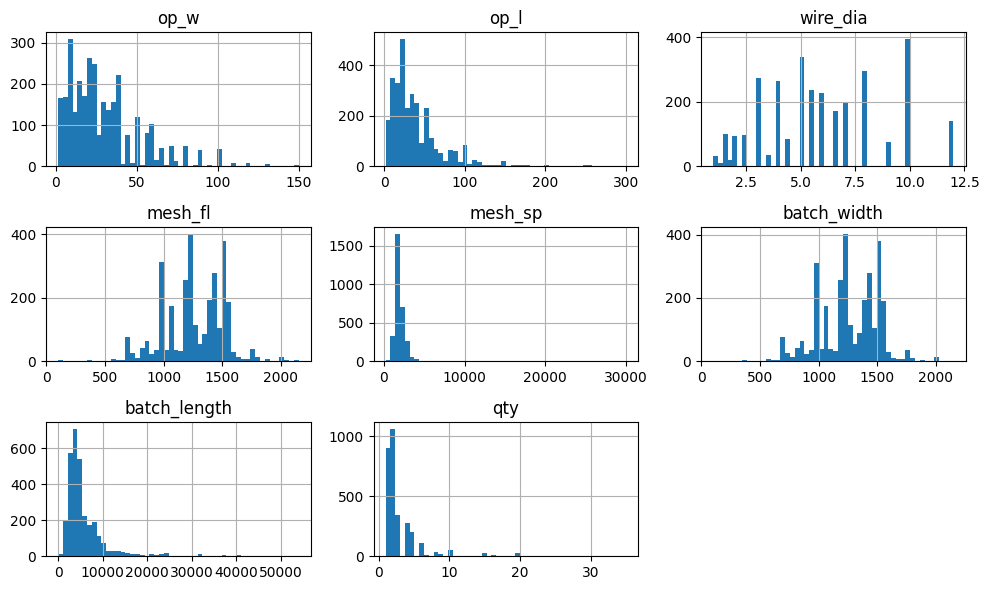

In [9]:
import matplotlib.pyplot as plt

numeric_cols = X_train.select_dtypes(include='number').columns
X_train[numeric_cols].hist(bins=50, figsize=(10, 6))
plt.tight_layout()
plt.show()

#### Candidate features for log transformation

In addition to basic statistics, the code evaluates the skewness of each numerical feature.

For features containing only positive values, skewness is calculated and variables with absolute skewness greater than 1 are marked as candidates for logarithmic transformation. Applying a log transformation can reduce the influence of extreme values, stabilize variance, and make feature distributions closer to normal.

However, inspection of the feature distributions suggests that several variables exhibit multimodal structure rather than simple right-skewness, raising doubt about the appropriateness of a log transformation for these features. The presence of multiple modes may indicate underlying subpopulations or complex relationships that a log transformation alone may not address.

Therefore, the identified variables are not transformed automatically at this stage. Instead, this step helps determine which preprocessing operations may improve the baseline model in later experiments.

In [10]:
from IPython.display import Markdown, display
display(Markdown(X_train[numeric_cols].describe().T.round(2).to_markdown()))
log_candidates = []
for col in numeric_cols:
    if (X_train[col] <= 0).any():
        continue
    skewness = X_train[col].skew()
    if abs(skewness) > 1:
        log_candidates.append(col)
print("Log transformation candidates:", log_candidates)

|              |   count |    mean |     std |   min |   25% |    50% |   75% |   max |
|:-------------|--------:|--------:|--------:|------:|------:|-------:|------:|------:|
| op_w         |    3089 |   30.22 |   22.96 |   1.5 |    13 |   25   |    40 |   150 |
| op_l         |    3089 |   39.61 |   34.48 |   1.5 |    18 |   30   |    50 |   300 |
| wire_dia     |    3089 |    6.01 |    2.78 |   1   |     4 |    5.5 |     8 |    12 |
| mesh_fl      |    3089 | 1262.62 |  257.59 | 100   |  1050 | 1240   |  1480 |  2150 |
| mesh_sp      |    3089 | 1973.76 | 1237.77 | 200   |  1500 | 1730   |  2230 | 30000 |
| batch_width  |    3089 | 1261.65 |  253.47 | 100   |  1050 | 1240   |  1480 |  2150 |
| batch_length |    3089 | 6077.16 | 5587.95 |   6.8 |  3200 | 4500   |  6600 | 54000 |
| qty          |    3089 |    3.01 |    3.12 |   1   |     1 |    2   |     4 |    35 |

Log transformation candidates: ['op_w', 'op_l', 'mesh_sp', 'batch_length', 'qty']


In [11]:
import numpy as np

log_candidates = []
log1p_candidates = []  # for features with zero values

for col in numeric_cols:
    skewness = X_train[col].skew()
    
    # looking for strong right skewness
    if skewness > 1:
        # positive values only
        if (X_train[col] > 0).all():
            log_candidates.append(col)
            
        # positive values and zeros (need for log1p to avoid log(0))
        elif (X_train[col] >= 0).all():
            log1p_candidates.append(col)
            
        # negative values present
        else:
            print(f"Column {col} has strong skewness ({skewness:.2f}) \n"
                  f"but contains negative values.")
            """
            Use one of the following strategies:
            - Yeo-Johnson transformation:
                from sklearn.preprocessing import PowerTransformer
                pt = PowerTransformer(method='yeo-johnson')
                X_train[col] = pt.fit_transform(X_train[[col]])
            - Arbitrary constant shift to make all values positive:
                shift = abs(X_train[col].min()) + 1
                X_train[col] = X_train[col] + shift
            - Sign preserving log transformation:
                X_train[col] = np.sign(X_train[col]) * np.log1p(np.abs(X_train[col]))
            """

print("Candidate features for Log np.log():", log_candidates)
print("Candidate features for Log(x+1) np.log1p():", log1p_candidates)


Candidate features for Log np.log(): ['op_w', 'op_l', 'mesh_sp', 'batch_length', 'qty']
Candidate features for Log(x+1) np.log1p(): []



---
### 1. Preprocessing Steps

The preprocessing stage is implemented using `Pipeline` and `ColumnTransformer` to ensure that all feature transformations are applied consistently during both training and evaluation.

Categorical variables are encoded using one-hot encoding with `handle_unknown="ignore"` to handle cases when unseen categories appear in validation or test data.

Numerical features are standardized using `StandardScaler`, which centers features around zero mean and unit variance.

Two preprocessing variants are prepared:

* a standard preprocessing pipeline with scaling only,
* a preprocessing pipeline that additionally applies logarithmic transformation to selected skewed numerical features before scaling.

The logarithmic transformation is implemented with `log1p`, which safely handles small positive values and zeros in test data. Feature selection for this transformation is based on the skewness analysis performed earlier.

The pipeline structure also isolates preprocessing logic from the model itself. This reduces the risk of data leakage and ensures reproducible transformations across experiments.


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
import numpy as np

cat_cols = ['op_align', 'stand_type']
num_cols = [c for c in X_train.columns if c not in cat_cols]

log_cols = log_candidates
normal_num_cols = [c for c in num_cols if c not in log_cols]

num_pipeline = Pipeline([
    (
        "feature_transforms",
        ColumnTransformer([
            (
                "log",
                FunctionTransformer(np.log1p, validate=False),
                log_cols
            ),
            (
                "normal",
                "passthrough",
                normal_num_cols
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False)
    ),

    ("scale", StandardScaler())
])

cat_step = (
    "cat", 
    OneHotEncoder(
        handle_unknown="ignore", 
        sparse_output=False
    ), 
    make_column_selector(dtype_include=['category', 'object'])
)
num_step = (
    "num", 
    StandardScaler(), 
    make_column_selector(dtype_include='number')
)
num_step_log = (
    "num", 
    num_pipeline, 
    make_column_selector(dtype_include='number')
)

preprocess_log = ColumnTransformer(
    transformers=[cat_step, num_step_log], 
    verbose_feature_names_out=False
    )

preprocess = ColumnTransformer(
    transformers=[cat_step, num_step], 
    verbose_feature_names_out=False
    )

Fit the preprocess pipeline on the training data

In [13]:
preprocess.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

Fit the log preprocess pipeline on the training data

In [14]:
preprocess_log.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

Preprocess step is fitted only on the training data to avoid data leakage - it shouldn't know the distribution of the test data during fitting. When we later transform the test data, it will use the same encoding and scaling parameters learned from the training data, ensuring that the test data is processed in a consistent way without introducing information from the test set into the training process.

In [15]:
feature_names = list(preprocess.get_feature_names_out())

print("Feature names after preprocessing:\n")
for i in range(0, len(feature_names), 4):
    print(feature_names[i:i+4])


Feature names after preprocessing:

['op_align_A', 'op_align_B', 'op_align_S', 'stand_type_A']
['stand_type_B', 'stand_type_C', 'stand_type_D', 'stand_type_E']
['op_w', 'op_l', 'wire_dia', 'mesh_fl']
['mesh_sp', 'batch_width', 'batch_length', 'qty']



---
### 2. Baseline modeling with Optuna

Baseline models are tuned using Optuna to obtain the best-performing configuration within each model family. The search is performed separately for linear models (Ridge, Lasso, ElasticNet) and tree-based models (XGBoost, LightGBM, RandomForest).

For each family, multiple trials are run with cross-validated RMSE as the optimization target. Each trial also evaluates different preprocessing strategies, including optional log-transformed features, to account for skewed numerical distributions.

The result of this process is not a single global model, but two representative baselines: one best linear model and one best tree-based model. These serve as reference points for later experiments, where the goal is to improve linear models through feature engineering and close the performance gap to more flexible tree-based approaches.


In [16]:
from IPython.display import display, Markdown
import pandas as pd

display(Markdown("### Target variable distribution in training set"))
display(pd.DataFrame({
    'Target Range': f"{y_train.min():.0f} - {y_train.max():.0f} minutes",
    'Target Mean': f"{y_train.mean():.0f} minutes"
}, index=['']))

### Target variable distribution in training set

,Target Range,Target Mean
,15 - 2100 minutes,102 minutes



##### Adaptive Budgeting for Efficient Hyperparameter Optimization

To efficiently allocate computational resources during hyperparameter optimization, an adaptive budgeting strategy is implemented. This approach dynamically adjusts the number of trials for each model family based on preliminary performance estimates inside each Optuna study. It basically estimates improvement of optimization on the fly and decides whether to continue searching for better configurations or to stop early (skipping further trials for given configuration) if the current best performance is unlikely to be surpassed.

Therefore global_budget value must be set to a sufficiently large number to allow for multiple trials including the skipped ones, while the actual number of trials executed for each model family may be significantly lower if early stopping conditions are met. This adaptive approach helps focus computational efforts on promising model configurations while avoiding unnecessary evaluations of underperforming setups.

In [17]:
# adaptive_budget.py
from collections import defaultdict
import numpy as np

class AdaptiveOptunaBudget:
    def __init__(
            self, 
            base_trials=20, 
            patience=15, 
            min_improve=1e-3,
            ascending=False
            ):
        self.base_trials = base_trials
        self.patience = patience
        self.min_improve = min_improve
        self.ascending = ascending

        self.best_score = defaultdict(
            lambda: np.inf if not self.ascending else -np.inf
        )
        self.no_improve = defaultdict(int)
        self.trials_done = defaultdict(int)

    def update(self, cfg_key, score):

        self.trials_done[cfg_key] += 1

        prev_best = self.best_score[cfg_key]

        if (
            not self.ascending and score < prev_best - self.min_improve
        ) or (
            self.ascending and score > prev_best + self.min_improve
        ):
            self.best_score[cfg_key] = score
            self.no_improve[cfg_key] = 0
        else:
            self.no_improve[cfg_key] += 1

    def should_stop(self, cfg_key):

        if self.trials_done[cfg_key] < self.base_trials:
            return False

        return self.no_improve[cfg_key] >= self.patience

Write script above to `notebooks/utils/utilities/adaptive_budget.py`.

In [18]:
from notebooks.utils.utilities.write_prev_cell import write_previous_cell_to_file

write_previous_cell_to_file(
    cell_code=_i, # type: ignore
    file_path='../utils/utilities/adaptive_budget.py'
)

`run_pipeline` - generic function to be used in objective function for Optuna studies, which runs the entire pipeline (preprocessing + model training) and returns the evaluation metric (RMSE) for given hyperparameters and preprocessing choice.

In [33]:
from lightgbm import LGBMRegressor
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

def run_pipeline(trial, cfg): 
    """ Function to run the training and evaluation pipeline 
        for a given Optuna trial and configuration. """
    
    model_type, use_log_preprocess, random_state = cfg

    if model_type == 'Ridge':
        model = Ridge(
            alpha=trial.suggest_float('ridge_alpha', 0.1, 100.0, log=True)
        )
    elif model_type == 'Lasso':
        model = Lasso(
            alpha=trial.suggest_float('lasso_alpha', 0.01, 10.0, log=True)
        )
    elif model_type == 'ElasticNet':
        model = ElasticNet(
            alpha=trial.suggest_float('elasticnet_alpha', 0.01, 10.0, log=True), 
            l1_ratio=trial.suggest_float('elasticnet_l1_ratio', 0.1, 0.9)
        )
    elif model_type == 'XGBRegressor':
        model = XGBRegressor(
            n_estimators=trial.suggest_int('xgb_n_estimators', 50, 300), 
            max_depth=trial.suggest_int('xgb_max_depth', 3, 10), 
            learning_rate=trial.suggest_float('xgb_learning_rate', 0.01, 0.3, log=True), 
            random_state=random_state,
            n_jobs=1
        )
    elif model_type == 'LGBMRegressor':
        model = LGBMRegressor(
            n_estimators=trial.suggest_int('lgb_n_estimators', 50, 300), 
            max_depth=trial.suggest_int('lgb_max_depth', 3, 10), 
            learning_rate=trial.suggest_float('lgb_learning_rate', 0.01, 0.3, log=True),
            random_state=random_state,
            n_jobs=1
        )
    elif model_type == 'RandomForestRegressor':
        model = RandomForestRegressor(
             n_estimators=trial.suggest_int('rf_n_estimators', 50, 300), 
             max_depth=trial.suggest_int('rf_max_depth', 3, 10),
             random_state=random_state,
             n_jobs=1
        )
    
    # build Pipeline
    pipeline = Pipeline([
        ("preprocess", preprocess_log if use_log_preprocess else preprocess),
        ("regressor", model)
    ])
    
    n_folds = 5

    # cross-validation evaluation
    scores = cross_validate(
        pipeline, X_train, y_train, 
        cv=n_folds, 
        scoring={
            'RMSE': 'neg_root_mean_squared_error', 
            'MAE': 'neg_mean_absolute_error', 
            'R^2': 'r2'
        },
        n_jobs=-1
    )
    
    # calculate the means
    mean_rmse = -scores['test_RMSE'].mean()
    mean_mae = -scores['test_MAE'].mean()
    mean_r2 = scores['test_R^2'].mean()

    # # fold scores
    # fold_scores = pd.DataFrame({
    #     'Fold': range(1, n_folds + 1),
    #     'RMSE': -scores['test_RMSE'],
    #     'MAE': -scores['test_MAE'],
    #     'R^2': scores['test_R^2']
    # })
    # trial.set_user_attr("fold_scores", fold_scores.to_dict(orient='list')) 
    
    # fold_RMSE
    trial.set_user_attr("fold_RMSE", (-scores['test_RMSE']).tolist())
    trial.set_user_attr("fold_MAE", (-scores['test_MAE']).tolist())
    trial.set_user_attr("fold_R2", (scores['test_R^2']).tolist())
    
    # write additional metrics to trial's user attributes
    trial.set_user_attr("RMSE", mean_rmse)
    trial.set_user_attr("MAE", mean_mae)
    trial.set_user_attr("R2", mean_r2)
    
    return mean_rmse


objective function for Optuna studies, which defines the search space for hyperparameters and preprocessing options, and calls `run_pipeline` to evaluate each trial's performance.

In [34]:
# objective function with adaptive budget
def objective_adaptive(        
        trial, 
        budget,
        models: list[str], 
        # variance_penalty=False,
        ):

    # trial.suggest_categorical('variance_penalty', [variance_penalty])

    cfg = (
        trial.suggest_categorical('model_type', models), 
        trial.suggest_categorical('use_log_preprocess', [True, False]),
        trial.suggest_categorical('random_state', [42])
    )

    # Check if we should stop early based on the adaptive budget
    if budget.should_stop(cfg):
        raise optuna.TrialPruned()

    score = run_pipeline(trial, cfg) #, variance_penalty=variance_penalty)

    budget.update(cfg, score)

    return score


Main execution block that runs Optuna studies for input configurations and aggregates results.

In [35]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

def run_optuna_studies_adaptive(configs, global_budget=1000):
    """ Main function to run Optuna studies with adaptive budget. """
    scores_list = []

    for cfg in configs:
        print(f"Optimizing {cfg.model}...")

        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=42),
            pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=10)
        )
        
        budget = AdaptiveOptunaBudget(
            base_trials=20,
            patience=45,
            min_improve=1e-3
        )

        study.optimize(
            lambda trial: objective_adaptive(
                trial, 
                budget=budget,
                models=[cfg.model],
                # variance_penalty=cfg.var_penalty
            ),
            n_trials=global_budget,
            n_jobs=1
        )

        converged = budget.no_improve[cfg] < budget.patience
        
        scores_list.append({
            'study': study,
            
            'Model': study.best_trial.params.get('model_type'),
            'Optuna Score': study.best_value,

            # # settings
            # 'Variance Penalty': '✔' if cfg.var_penalty else '',
            'Use Log Preprocess': '✔' if study.best_trial.params.get('use_log_preprocess', False) else '',

            # main regression metrics
            'RMSE': study.best_trial.user_attrs.get("RMSE", None),
            'MAE': study.best_trial.user_attrs.get("MAE", None),
            'R2': study.best_trial.user_attrs.get("R2", None),
            'RMSE Std': study.best_trial.user_attrs.get("RMSE_std", None),

            # stability and convergence indicators
            'Condition Number': study.best_trial.user_attrs.get("condition_number", None),
            'Converged': '✔' if converged else '✘',

            'Best': '',

            # additional info for analysis
            'base_model': study.best_trial.params.get('model_type').lower(),
            'best_params': study.best_params,
            'fold_scores': {
                'RMSE': study.best_trial.user_attrs['fold_RMSE'],
                'MAE': study.best_trial.user_attrs['fold_MAE'],
                'R2': study.best_trial.user_attrs['fold_R2']
            },
        })
    
    return scores_list

Helper to display Optuna study results.

In [36]:
def mark_best_models(
        df, 
        score_col='Optuna Score', 
        group_col='Model', 
        ascending=True
        ):
    """ Marks the best model per group based on the specified score column."""
    for model in df[group_col].unique():
        if ascending:
            best_idx = df[df[group_col] == model][score_col].idxmin()
        else:
            best_idx = df[df[group_col] == model][score_col].idxmax()
        df.loc[best_idx, 'Best'] = '✔'


def display_optuna_results(
        scores_list,
        sort_by='Optuna Score',
        subset_cols=['Model', 'Use Clusterer', 'Use Poly'],

        best_in_group='Optuna Score',
        group_by='Model',
        best_ascending=True,

        std_metrics=True, 
        quantile_metrics=False,
        additional_metrics_cols=[]
        ):
    
    display_columns = subset_cols + ['Optuna Score'] + (
        ['RMSE', 'MAE', 'R2'] if std_metrics else []
    ) + additional_metrics_cols + (
        ['pinball_loss', 'coverage', 'coverage_error'] if quantile_metrics else []
    ) # + ['Best']

    df = (pd.DataFrame(scores_list)
        .sort_values(sort_by)
        .drop_duplicates(subset=subset_cols, keep='first')
        .fillna('')
        .reset_index(drop=True))

    mark_best_models(
        df, 
        score_col=best_in_group, 
        group_col=group_by, 
        ascending=best_ascending)

    display(df[display_columns])

    if best_in_group and group_by and 'Best' in display_columns:
        display(Markdown(
            f"**Note:** Best '{best_in_group}' per '{group_by}' "
            f"are marked with ✔ in the 'Best' column."))


    display(Markdown("#### Best Model Hyperparameters"))
    display(pd.DataFrame([
        df
        .sort_values('RMSE')['best_params']
        .reset_index(drop=True)
        .loc[0]
    ]).set_index(['model_type']).T)

    display(Markdown("#### Fold Scores for Best Model"))
    fold_scores = (
        df
        .sort_values('RMSE')['fold_scores']
        .reset_index(drop=True).loc[0]
    )
    # display(pd.DataFrame(fold_scores).round(4).set_index('Fold').T)
    display(pd.DataFrame(fold_scores).round(4).T.rename_axis('Fold', axis=1))


##### Configurations for Linear Models and Tree-based Models
The configurations for Optuna studies are defined separately for linear and tree-based models.

In [37]:
from dataclasses import dataclass

@dataclass(frozen=True)
class BaselineExperimentConfig:
    model: str

configs_baseline_tree = [
    BaselineExperimentConfig(model=model)
    for model in ['XGBRegressor', 'LGBMRegressor', 'RandomForestRegressor']
]

configs_baseline_linear = [
    BaselineExperimentConfig(model=model)
    for model in ['Ridge', 'Lasso', 'ElasticNet']
]

Execute Optuna studies

In [38]:
scores_list_linear = run_optuna_studies_adaptive(configs_baseline_linear, global_budget=1000)

Optimizing Ridge...
Optimizing Lasso...
Optimizing ElasticNet...


In [39]:
scores_list_tree = run_optuna_studies_adaptive(configs_baseline_tree, global_budget=1000)

Optimizing XGBRegressor...
Optimizing LGBMRegressor...
Optimizing RandomForestRegressor...


In [40]:
display_optuna_results(
    scores_list=scores_list_linear, 
    sort_by='Optuna Score',
    subset_cols=['Model', 'Use Log Preprocess'],
)

,Model,Use Log Preprocess,Optuna Score,RMSE,MAE,R2
0,Lasso,,62.339818,62.339818,26.264436,0.614040
1,ElasticNet,,62.341431,62.341431,26.295988,0.614099
2,Ridge,,62.345481,62.345481,26.302924,0.614060


#### Best Model Hyperparameters

model_type,Lasso
use_log_preprocess,False
random_state,42
lasso_alpha,0.122604


#### Fold Scores for Best Model

Fold,0,1,2,3,4
RMSE,51.7162,84.5791,69.7811,43.7472,61.8755
MAE,23.9561,29.6952,27.4503,23.9644,26.2560
R2,0.6393,0.4687,0.5212,0.7595,0.6815


In [102]:
display_optuna_results(
    scores_list=scores_list_tree,
    sort_by='Optuna Score', 
    subset_cols=['Model', 'Use Log Preprocess'],
)

,Model,Use Log Preprocess,Optuna Score,RMSE,MAE,R2
0,XGBRegressor,,40.494861,40.494861,17.948287,0.829988
1,LGBMRegressor,,41.532358,41.532358,18.607715,0.820925
2,RandomForestRegressor,✔,42.401847,42.401847,19.053643,0.815157


#### Best Model Hyperparameters

model_type,XGBRegressor
use_log_preprocess,False
random_state,42
xgb_n_estimators,216
xgb_max_depth,3
xgb_learning_rate,0.062902


#### Fold Scores for Best Model

Fold,0,1,2,3,4
RMSE,34.8791,54.4647,54.3403,26.7452,32.0450
MAE,16.5260,19.3079,19.6047,16.2821,18.0208
R2,0.8359,0.7797,0.7096,0.9101,0.9146


##### Baseline results summary

After Adaptive Optuna trials with 1000 trials global budget per model, the linear baseline models converge to very similar performance. Lasso achieves the best results among them, with an RMSE of ~62.34 and R² around 0.61. Ridge and ElasticNet perform nearly identically, with slightly higher RMSE and lower R². None of the linear models used log-transformed features in their best configurations, suggesting that the skewness of numerical features may not be the primary factor limiting their performance.

The fold-level results show noticeable variance in performance across splits, with R² ranging from ~0.47 to ~0.76. This indicates that linear models struggle with stability across different data partitions, likely due to non-linear structure in the feature space that cannot be captured by simple additive relationships specific to each fold. The relatively low R² values also suggest that linear models are missing a significant portion of the underlying signal, which motivates the exploration of further feature engineering.

In contrast, tree-based models achieve substantially stronger performance. XGBoost is the best-performing model overall, reaching an RMSE of ~40.49 and R² close to 0.83. RandomForest and LightGBM follow closely but remain slightly weaker. The best XGBoost configuration uses shallow trees (max_depth=3) and a relatively low learning rate, combined with logarithmic preprocessing, which suggests that non-linearities were effectively discovered by simple tree structures and to most of the signal has been captured by the model.

This performance gap between linear and tree-based models becomes the key motivation for the next phase of the project, where the focus will be on engineering features that can help linear models better capture the underlying data structure and close the gap to more flexible tree-based approaches.

Linear models armored with various preprocessing strategies are considered noticably less computationally expensive to train and tune compared to tree-based models, which is an important consideration for iterative experimentation and deployment scenarios.

##### Select the best model based on Optuna scores
The best model is selected based on the lowest RMSE achieved in the Optuna studies. The study with the best RMSE is identified for both linear and tree-based models, and the overall best model is chosen by comparing these two top performers. This selection process ensures that the final baseline model represents the best possible configuration found during the hyperparameter optimization phase.

In [42]:
def get_best_baseline_model(study):
    """ Builds the best model pipeline based on the provided Optuna study results.
        The pipeline includes the selected preprocessing approach (log vs normal) 
        and the best performing model with its optimal hyperparameters.
    """
    return Pipeline([
        ("preprocess", preprocess_log if study.best_params['use_log_preprocess'] else preprocess),
        ("regressor", 
            Ridge(
                alpha=study.best_params['ridge_alpha']
            ) if study.best_params['model_type'] == 'Ridge' else
            Lasso(
                alpha=study.best_params['lasso_alpha']
            ) if study.best_params['model_type'] == 'Lasso' else
            ElasticNet(
                alpha=study.best_params['elasticnet_alpha'], 
                l1_ratio=study.best_params['elasticnet_l1_ratio']
            ) if study.best_params['model_type'] == 'ElasticNet' else
            XGBRegressor(
                n_estimators=study.best_params['xgb_n_estimators'],
                max_depth=study.best_params['xgb_max_depth'],
                learning_rate=study.best_params['xgb_learning_rate'],
                random_state=42,
                n_jobs=-1
            ) if study.best_params['model_type'] == 'XGBRegressor' else
            LGBMRegressor(
                n_estimators=study.best_params['lgb_n_estimators'],
                max_depth=study.best_params['lgb_max_depth'],
                learning_rate=study.best_params['lgb_learning_rate'],
                random_state=42,
                n_jobs=-1
            ) if study.best_params['model_type'] == 'LGBMRegressor' else
            RandomForestRegressor(
                n_estimators=study.best_params['rf_n_estimators'],
                max_depth=study.best_params['rf_max_depth'],
                random_state=42,
                n_jobs=-1
            )
        )
    ])


In [43]:
df_studies_linear = pd.DataFrame(scores_list_linear).sort_values('Optuna Score')
df_studies_tree = pd.DataFrame(scores_list_tree).sort_values('Optuna Score')

study_linear = df_studies_linear.iloc[0]['study']
study_tree = df_studies_tree.iloc[0]['study']

##### Select the best Linear model based on RMSE

In [44]:
best_linear_model = get_best_baseline_model(study_linear)
best_linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

##### Select the best overall model based on RMSE

In [45]:
study = (
    study_linear 
    if df_studies_linear['RMSE'].iloc[0] < df_studies_tree['RMSE'].iloc[0] 
    else study_tree
)

best_model = get_best_baseline_model(study)
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [46]:
# # MOVE IT TO EVALUATION NOTEBOOK LATER - TO COMPARE WITH FINAL MODEL
# y_pred = best_model.predict(X_test)

# # score
# from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
# rmse = root_mean_squared_error(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f"Test RMSE: {rmse:.2f}")
# print(f"Test MAE: {mae:.2f}")
# print(f"Test R^2: {r2:.4f}")

##### Registering the preprocessor in MLflow

In [ ]:
import mlflow.sklearn

# ========================================
# Preprocess Pipeline Logging
# ========================================
with mlflow.start_run(run_name="baseline_model") as run:

    print("Logging preprocess pipeline to MLflow...")
    mlflow.sklearn.log_model(
        preprocess, 
        name="preprocess_pipeline_step",
        registered_model_name="preprocess_pipeline",
        pyfunc_predict_fn="transform"
    )
    print(f"Logged preprocess pipeline to MLflow with run ID: {run.info.run_id}")
    print("""
To load the preprocess pipeline later:
preprocessor = mlflow.sklearn.load_model("models:/preprocess_pipeline/latest")
    """)

# ========================================
# Preprocess Log Pipeline Logging
# ========================================
with mlflow.start_run(run_name="baseline_model") as run:

    print("Logging preprocess log pipeline to MLflow...")
    mlflow.sklearn.log_model(
        preprocess_log, 
        name="preprocess_log_pipeline_step",
        registered_model_name="preprocess_log_pipeline",
        pyfunc_predict_fn="transform"
    )
    print(f"Logged preprocess log pipeline to MLflow with run ID: {run.info.run_id}")
    print("""
To load the preprocess log pipeline later:
preprocessor = mlflow.sklearn.load_model("models:/preprocess_log_pipeline/latest")
    """)

# ========================================
# Best Linear Model Logging
# ========================================
with mlflow.start_run(run_name="linear_baseline_model") as run:

    print("Logging parameters and metrics of the best linear model...")
    mlflow.log_params(study_linear.best_params)
    mlflow.log_metric("rmse", study_linear.best_trial.value)
    mlflow.log_metric("mae", study_linear.best_trial.user_attrs['MAE'])
    mlflow.log_metric("r2", study_linear.best_trial.user_attrs['R2'])

    print("Logging best linear model to MLflow...")
    mlflow.sklearn.log_model(
        best_linear_model, 
        name="linear_baseline_model",
        registered_model_name="linear_baseline_model",
        pyfunc_predict_fn="predict"
    )
    print("""
To load the linear baseline model later:
linear_baseline_model = mlflow.sklearn.load_model("models:/linear_baseline_model/latest")
    """)

# ========================================
# Best Model Logging
# ========================================
with mlflow.start_run(run_name="baseline_model") as run:
    print("Logging parameters and metrics of the best baseline model...")
    mlflow.log_params(study.best_params)
    mlflow.log_metric("rmse", study.best_trial.value)
    mlflow.log_metric("mae", study.best_trial.user_attrs['MAE'])
    mlflow.log_metric("r2", study.best_trial.user_attrs['R2'])

    print("Logging best baseline model to MLflow...")
    mlflow.sklearn.log_model(
        best_model, 
        name="baseline_model",
        registered_model_name="baseline_model",
        pyfunc_predict_fn="predict"
    )

    print("""
To load the baseline model later:
baseline_model = mlflow.sklearn.load_model("models:/baseline_model/latest")
    """)

2026/05/20 19:18:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logging preprocess pipeline to MLflow...


Registered model 'preprocess_pipeline' already exists. Creating a new version of this model...
Created version '8' of model 'preprocess_pipeline'.
2026/05/20 19:18:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged preprocess pipeline to MLflow with run ID: d87ff481f8fe42e0971fc895806a5be7

To load the preprocess pipeline later:
preprocessor = mlflow.sklearn.load_model("models:/preprocess_pipeline/latest")
    
Logging preprocess log pipeline to MLflow...


Successfully registered model 'preprocess_log_pipeline'.
Created version '1' of model 'preprocess_log_pipeline'.
2026/05/20 19:18:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged preprocess log pipeline to MLflow with run ID: 6922075fdb46493ba9b9e898f4eac7e1

To load the preprocess log pipeline later:
preprocessor = mlflow.sklearn.load_model("models:/preprocess_log_pipeline/latest")
    
Logging parameters and metrics of the best linear model...
Logging best linear model to MLflow...


Registered model 'linear_baseline_model' already exists. Creating a new version of this model...
Created version '4' of model 'linear_baseline_model'.
2026/05/20 19:18:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



To load the linear baseline model later:
linear_baseline_model = mlflow.sklearn.load_model("models:/linear_baseline_model/latest")
    
Logging parameters and metrics of the best baseline model...
Logging best baseline model to MLflow...

To load the baseline model later:
baseline_model = mlflow.sklearn.load_model("models:/baseline_model/latest")
    


Registered model 'baseline_model' already exists. Creating a new version of this model...
Created version '4' of model 'baseline_model'.


#### Retrieve and display metrics for the best runs

In [122]:
# get_run_metrics.py
from mlflow.tracking import MlflowClient

def get_latest_metrics_for_run(
        run_name="baseline_model", 
        experiment_name="Production Time Prediction",
        client=MlflowClient(),
        verbose=True
    ):

    runs = client.search_runs(
        experiment_ids=[client.get_experiment_by_name(experiment_name).experiment_id],
        filter_string=f"tags.mlflow.runName = '{run_name}'",
        order_by=["start_time DESC"],
        max_results=1
    )

    if runs:
        # print(runs[0].data)
        metrics_lower = {k.lower(): v for k, v in runs[0].data.metrics.items()}
        required_metrics = ['rmse', 'mae', 'r2']
        if all(metric in metrics_lower for metric in required_metrics):
            latest_rmse = metrics_lower['rmse']
            latest_mae = metrics_lower['mae']
            latest_r2 = metrics_lower['r2']
            
            if verbose:
                print(f"\nLatest run of '{run_name}' metrics:\n{50*'-'}")
                print(f"Best RMSE: {latest_rmse}")
                print(f"Best MAE: {latest_mae}")
                print(f"Best R2: {latest_r2}")
                print(f"Model parameters:")
                for param, value in runs[0].data.params.items():
                    print(f"  {param}: {value}")

            return latest_rmse, latest_mae, latest_r2, runs[0].data.params
        else:
            print(f"Metrics 'RMSE', 'MAE', or 'R2' not found in the latest run of '{run_name}'.")
    else:
        print(f"No runs found in the '{experiment_name}' experiment.")

    return None, None, None

##### Save `get_latest_metrics_for_run` function
to file: `notebooks/utils/utilities/get_run_metrics.py`

In [123]:
from notebooks.utils.utilities.write_prev_cell import write_previous_cell_to_file

write_previous_cell_to_file(
    cell_code=_i, # type: ignore
    file_path="../utils/utilities/get_run_metrics.py",
    )

Test the function by retrieving metrics

In [126]:
from notebooks.utils.utilities.get_run_metrics import get_latest_metrics_for_run

client = MlflowClient()
# target_run_name = "optuna_linear_models_ElasticNet_without_clusterer" 
for run_name in ["linear_baseline_model", "baseline_model"]:
    get_latest_metrics_for_run(run_name=run_name, client=client, verbose=True)


Latest run of 'linear_baseline_model' metrics:
--------------------------------------------------
Best RMSE: 62.33981794748693
Best MAE: 26.264436182119077
Best R2: 0.6140397303275258
Model parameters:
  model_type: Lasso
  use_log_preprocess: False
  random_state: 42
  lasso_alpha: 0.12260383628250535

Latest run of 'baseline_model' metrics:
--------------------------------------------------
Best RMSE: 40.49486083984375
Best MAE: 17.94828681945801
Best R2: 0.8299875617027282
Model parameters:
  model_type: XGBRegressor
  use_log_preprocess: False
  random_state: 42
  xgb_n_estimators: 216
  xgb_max_depth: 3
  xgb_learning_rate: 0.06290190119218095


run names for later retrieval of metrics:
- "linear_baseline_model" for the best linear model,
- "baseline_model" for the best overall model (which is a tree-based model).

---
---